# Script to query ClinVar's API so we can tell how many dominant pathogenic mutations a gene may contain.

In [1]:
# load libraries
import json
from math import isnan
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import requests
import time
import urllib.request
from urllib.error import HTTPError
import time
from collections import defaultdict
from ast import literal_eval

## Load data

In [ ]:
exon_file='../../data/dnd_ensembl/dnd_ensembl_data.csv'
data=pd.read_csv(exon_file)

In [2]:
data=pd.read_excel('/Users/graceramey/Desktop/UCSF/CapraLab/Conklin_Collabs/Data/GeneSets/dHS/2025-11-13/master_dataframe/dnd_593_2025_12_23.xlsx')
data.columns

Index(['hgnc_symbol', 'GENE ID (HGNC)', 'Approved name', 'DISEASE LABEL',
       'DISEASE ID (MONDO)', 'MOI', 'CLASSIFICATION', 'HI Score', '%HI', 'pLI',
       'LOEUF', 'total_plp', 'missense_plp', 'nonsense_plp', 'ensg', 'chrom',
       's_het', 's_het_lower_CI', 's_het_upper_CI',
       'indel_targetable_pre_NMD_assessment',
       'num_indel_vars_pre_NMD_assessment',
       'num_indel_amenable_vars_inducing_NMD',
       'num_indel_amenable_vars_escaping_NMD',
       'indel_targetable_post_NMD_assessment', 'crisproff_targetable',
       'num_crisproff_vars', 'base_editable', 'num_base_editable_vars',
       'excision_targetable', 'num_excision_vars', 'num_excision_pairs',
       'HPO_term_list', 'indel_pam_targetable', 'crisproff_pam_targetable',
       'base_edit_pam_targetable', 'excision_pam_targetable',
       'hets_across_strats', 'prop_hets_across_strats', 'num_indel_hets',
       'indel_hets_prop', 'num_crisproff_hets', 'crisproff_hets_prop',
       'num_base_edit_hets', 'bas

In [4]:
gene_df=data[['hgnc_symbol']].drop_duplicates() # isolate just the gene names

In [5]:
# sort gene names
gene_df.sort_values(by='hgnc_symbol', inplace=True, ignore_index=True)
gene_df

,hgnc_symbol
0,AARS1
1,ABCB6
2,ABCC6
3,ABCC8
4,ABCC9
...,...
588,ZIC1
589,ZMIZ1
590,ZMYND8
591,ZNF292


In [6]:
# =========================
# SETUP QUERY LINKS
# =========================
base_esearch = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
base_epost  = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/epost.fcgi"
base_esummary = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

record_list = []
mutation_nums = []
mis_mutation_nums = []
ns_mutation_nums = []
counter_list = []

session = requests.Session()  # reuse connections

# =========================
# CHECKPOINT CONFIG
# =========================

CHECKPOINT_DIR = os.path.join(os.getcwd(), "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_EVERY_N_GENES = 10  # hard checkpoint interval

PER_GENE_CSV = os.path.join(CHECKPOINT_DIR, "per_gene_checkpoint.csv")
ROLLING_CSV  = os.path.join(CHECKPOINT_DIR, "rolling_checkpoint.csv")

# =========================
# ClinVar JSON max
# =========================
ESUMMARY_PAGE_SIZE = 500

ALLOWED_GERMLINE = {
    "Pathogenic",
    "Likely pathogenic",
    "Pathogenic/Likely pathogenic",
}

# =========================
# HELPERS
# =========================
def batched(iterable, n):
    for i in range(0, len(iterable), n):
        yield iterable[i:i + n]


def request_with_429_retry(
    method,
    url,
    *,
    params=None,
    data=None,
    timeout=60,
    sleep_on_429=1.0,
    max_tries=10,
):
    for _attempt in range(max_tries):
        r = session.request(method, url, params=params, data=data, timeout=timeout)
        if r.status_code != 429:
            r.raise_for_status()
            return r
        print(f"429 from {url.split('/')[-1]} ; sleeping {sleep_on_429}s and retrying…")
        time.sleep(sleep_on_429)
    raise RuntimeError(f"Too many 429s from {url} after {max_tries} tries")


def epost_ids(db, ids):
    r = request_with_429_retry(
        "POST",
        base_epost,
        data={"db": db, "id": ",".join(ids)},
        timeout=60,
    )
    txt = r.text
    webenv = txt.split("<WebEnv>")[1].split("</WebEnv>")[0]
    query_key = txt.split("<QueryKey>")[1].split("</QueryKey>")[0]
    return webenv, query_key


def esummary_from_history(db, webenv, query_key, retstart, retmax):
    params = {
        "db": db,
        "query_key": query_key,
        "WebEnv": webenv,
        "retmode": "json",
        "retstart": retstart,
        "retmax": retmax,
    }
    r = request_with_429_retry("GET", base_esummary, params=params, timeout=60)
    data = r.json()
    if "error" in data:
        raise RuntimeError(f"ClinVar esummary error: {data['error']}")
    return data


def save_checkpoint(counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums):
    df = pd.DataFrame({
        "counter": counter_list,
        "gene": gene_list,
        "total_plp": mutation_nums,
        "missense_plp": mis_mutation_nums,
        "nonsense_plp": ns_mutation_nums,
    })
    df.to_csv(ROLLING_CSV, index=False)


def append_per_gene_row(counter, gene, total_plp, mis_plp, ns_plp):
    row = pd.DataFrame([{
        "counter": counter,
        "gene": gene,
        "total_plp": total_plp,
        "missense_plp": mis_plp,
        "nonsense_plp": ns_plp,
    }])
    header = not os.path.exists(PER_GENE_CSV)
    row.to_csv(PER_GENE_CSV, mode="a", header=header, index=False)


def load_checkpoint():
    """
    Returns:
      done_counters: set[int]
      counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums: lists
    """
    if not os.path.exists(PER_GENE_CSV):
        return set(), [], [], [], [], []

    df = pd.read_csv(PER_GENE_CSV)

    # Normalize / guard
    if df.empty:
        return set(), [], [], [], [], []

    # If you re-ran and appended duplicates, keep the last occurrence per counter.
    df = df.sort_values("counter").drop_duplicates(subset=["counter"], keep="last")

    done_counters = set(df["counter"].astype(int).tolist())

    counter_list = df["counter"].astype(int).tolist()
    gene_list = df["gene"].astype(str).tolist()
    mutation_nums = df["total_plp"].astype(int).tolist()
    mis_mutation_nums = df["missense_plp"].astype(int).tolist()
    ns_mutation_nums = df["nonsense_plp"].astype(int).tolist()

    return done_counters, counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums


# =========================
# RESUME STATE
# =========================
done_counters, counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums = load_checkpoint()

if done_counters:
    print(f"Resuming from checkpoint: {len(done_counters)} genes already completed.")
    print(f"Last completed counter: {max(done_counters)}")
else:
    print("No checkpoint found. Starting fresh.")

# This list is only used for debugging / optional record keeping
record_list = []  # NOTE: not checkpointed (can be huge); remove if you don't need it.


# Main loop below
# =========================
# MAIN LOOP (RESUMABLE)
# =========================
for counter, gene in enumerate(gene_df["hgnc_symbol"]):
    if counter in done_counters:
        continue

    print(f"{counter}  {gene}")

    # note how we're filtering by mutations annotated as 'dominant' here
    term = (
        f'{gene}[gene] AND single_gene[prop] AND "moi autosomal dominant"[prop] AND '
        '(pathogenic[clinsig] OR "likely pathogenic"[clinsig] OR "pathogenic/likely pathogenic"[clinsig])'
    )

    esearch_params = {"db": "clinvar", "term": term, "retmode": "json", "retmax": 100000}
    r = request_with_429_retry("GET", base_esearch, params=esearch_params, timeout=30)
    esearch_data = r.json()

    cur_ids = esearch_data["esearchresult"]["idlist"]
    record_list.append(cur_ids)

    # STRICT aggregate germline P/LP-only counts
    p_lp_mutation_counter = 0
    mis_plp_mutation_counter = 0
    ns_plp_mutation_counter = 0

    if cur_ids:
        for post_batch in batched(cur_ids, 5000):
            webenv, query_key = epost_ids("clinvar", post_batch)

            retstart = 0
            while retstart < len(post_batch):
                esum_data = esummary_from_history(
                    "clinvar",
                    webenv,
                    query_key,
                    retstart=retstart,
                    retmax=ESUMMARY_PAGE_SIZE,
                )
                #print(len(esum_data.get("result", {}).get("uids", [])))
                for uid in esum_data.get("result", {}).get("uids", []):
                    cur_uid_result = esum_data["result"].get(uid, {})

                    germ_desc = (
                        cur_uid_result
                        .get("germline_classification", {})
                        .get("description", "")
                        .strip()
                    )
                    if germ_desc not in ALLOWED_GERMLINE:
                        continue

                    p_lp_mutation_counter += 1

                    mcons = cur_uid_result.get("molecular_consequence_list", [])
                    mcons_text = " ".join(
                        (mc.get("type", "") if isinstance(mc, dict) else str(mc))
                        for mc in mcons
                    ).lower()

                    if "missense" in mcons_text:
                        mis_plp_mutation_counter += 1
                    if ("nonsense" in mcons_text) or ("stop_gained" in mcons_text):
                        ns_plp_mutation_counter += 1

                retstart += ESUMMARY_PAGE_SIZE
                time.sleep(0.35)

    # Store in-memory
    counter_list.append(counter)
    gene_list.append(gene)
    mutation_nums.append(p_lp_mutation_counter)
    mis_mutation_nums.append(mis_plp_mutation_counter)
    ns_mutation_nums.append(ns_plp_mutation_counter)

    # Append-only per-gene checkpoint
    append_per_gene_row(counter, gene, p_lp_mutation_counter, mis_plp_mutation_counter, ns_plp_mutation_counter)

    # Update done set
    done_counters.add(counter)

    # Periodic rolling checkpoint
    if counter % CHECKPOINT_EVERY_N_GENES == 0 and counter > 0:
        save_checkpoint(counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums)

    time.sleep(0.35)

# Final rolling checkpoint
save_checkpoint(counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums)

print("Done. Final checkpoints written:")
print(f"  Per-gene:  {PER_GENE_CSV}")
print(f"  Rolling:   {ROLLING_CSV}")

SyntaxError: invalid syntax (310115180.py, line 20)

In [8]:
# merge with existing data
mutation_df = pd.DataFrame({
    'hgnc_symbol':gene_list,
    'dominant_plp_mutations':mutation_nums,
    'dominant_mis_plp_mutations':mis_mutation_nums,
    'dominant_ns_plp_mutations':ns_mutation_nums
})
mutation_df

,hgnc_symbol,dominant_plp_mutations,dominant_mis_plp_mutations,dominant_ns_plp_mutations
0,AARS1,4,2,0
1,ABCB6,2,1,0
2,ABCC6,1,0,1
3,ABCC8,10,7,0
4,ABCC9,6,6,0
...,...,...,...,...
588,ZIC1,0,0,0
589,ZMIZ1,4,1,2
590,ZMYND8,1,0,0
591,ZNF292,23,1,9


In [ ]:
mutation_df[mutation_df['hgnc_symbol'].isin(['MYH7','NEFL'])]

## Hmmm, the dominant mutation numbers get quite small here.
That's not because they are, it's just the dominant annotations are lacking in ClinVar, so the real number is probably much higher than what we're seeing. We know this because genes like MYH7 and NEFL are annotated to have many fewer dominant mutations than what the literature reports.

# Now let's see if we can get more accurate dominant pathogenic mutation prevalence by overlapping the names of the linked dominant diseases in ClinGen with the names in ClinVar

In [143]:
## install fuzzywuzzy and python-Levenshtein packages for string matching
#!pip install fuzzywuzzy python-Levenshtein

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.6/158.6 kB 3.2 MB/s eta 0:00:004.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.5 MB/s eta 0:00:000m eta 0:00:010:01


In [18]:
# load some packages that will help with fuzzy string matching
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

In [19]:
# load disease names from original file
data_ad = data[data['MOI'].isin(['AD','SD'])]
dis = data_ad[['hgnc_symbol','DISEASE LABEL','DISEASE ID (MONDO)']]
dis

,hgnc_symbol,DISEASE LABEL,DISEASE ID (MONDO)
0,AARS1,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212
1,AARS1,AARS1-related leukoencephalopathy,MONDO:1010132
2,ABCB6,"microphthalmia, isolated, with coloboma 7",MONDO:0013783
3,ABCB6,dyschromatosis universalis hereditaria 3,MONDO:0014169
4,ABCC6,inherited pseudoxanthoma elasticum,MONDO:0100091
...,...,...,...
850,ZIC1,craniosynostosis 6,MONDO:0014705
851,ZMIZ1,complex neurodevelopmental disorder,MONDO:0100038
852,ZMYND8,syndromic complex neurodevelopmental disorder,MONDO:0800439
853,ZNF292,complex neurodevelopmental disorder,MONDO:0100038


# Currently working on this setup

In [141]:
# set up the ClinVar query below, including string matching

# =========================
# SETUP QUERY LINKS
# =========================
base_esearch = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
base_epost  = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/epost.fcgi"
base_esummary = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

record_list = []
mutation_nums = []
mis_mutation_nums = []
ns_mutation_nums = []
counter_list = []
dom_ids_list=[]

session = requests.Session()  # reuse connections

# =========================
# CHECKPOINT CONFIG
# =========================
CHECKPOINT_DIR = "/Users/graceramey/Desktop/UCSF/CapraLab/Conklin_Collabs/Data/GeneSets/dHS/2025-11-13/ClinVar_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_EVERY_N_GENES = 10  # hard checkpoint interval

PER_GENE_CSV = os.path.join(CHECKPOINT_DIR, "per_gene_checkpoint_dis_matching.csv")
ROLLING_CSV  = os.path.join(CHECKPOINT_DIR, "rolling_checkpoint_dis_matching.csv")

# =========================
# ClinVar JSON max
# =========================
ESUMMARY_PAGE_SIZE = 500

ALLOWED_GERMLINE = {
    "Pathogenic",
    "Likely pathogenic",
    "Pathogenic/Likely pathogenic",
}

# =========================
# HELPERS
# =========================
def batched(iterable, n):
    for i in range(0, len(iterable), n):
        yield iterable[i:i + n]


def request_with_429_retry(
    method,
    url,
    *,
    params=None,
    data=None,
    timeout=60,
    sleep_on_429=1.0,
    max_tries=10,
):
    for _attempt in range(max_tries):
        r = session.request(method, url, params=params, data=data, timeout=timeout)
        if r.status_code != 429:
            r.raise_for_status()
            return r
        print(f"429 from {url.split('/')[-1]} ; sleeping {sleep_on_429}s and retrying…")
        time.sleep(sleep_on_429)
    raise RuntimeError(f"Too many 429s from {url} after {max_tries} tries")


def epost_ids(db, ids):
    r = request_with_429_retry(
        "POST",
        base_epost,
        data={"db": db, "id": ",".join(ids)},
        timeout=60,
    )
    txt = r.text
    webenv = txt.split("<WebEnv>")[1].split("</WebEnv>")[0]
    query_key = txt.split("<QueryKey>")[1].split("</QueryKey>")[0]
    return webenv, query_key


def esummary_from_history(db, webenv, query_key, retstart, retmax):
    params = {
        "db": db,
        "query_key": query_key,
        "WebEnv": webenv,
        "retmode": "json",
        "retstart": retstart,
        "retmax": retmax,
    }
    r = request_with_429_retry("GET", base_esummary, params=params, timeout=60)
    data = r.json()
    if "error" in data:
        raise RuntimeError(f"ClinVar esummary error: {data['error']}")
    return data


def save_checkpoint(counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums, dom_ids_list):
    df = pd.DataFrame({
        "counter": counter_list,
        "gene": gene_list,
        "total_plp": mutation_nums,
        "missense_plp": mis_mutation_nums,
        "nonsense_plp": ns_mutation_nums,
        "dom_ids_list": dom_ids_list
    })
    df.to_csv(ROLLING_CSV, index=False)


def append_per_gene_row(counter, gene, total_plp, mis_plp, ns_plp, dom_ids_list):
    row = pd.DataFrame([{
        "counter": counter,
        "gene": gene,
        "total_plp": total_plp,
        "missense_plp": mis_plp,
        "nonsense_plp": ns_plp,
        "dom_ids_list": dom_ids_list
    }])
    header = not os.path.exists(PER_GENE_CSV)
    row.to_csv(PER_GENE_CSV, mode="a", header=header, index=False)


def load_checkpoint():
    """
    Returns:
      done_counters: set[int]
      counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums, dom_ids_list: lists
    """
    if not os.path.exists(PER_GENE_CSV):
        return set(), [], [], [], [], [], []

    df = pd.read_csv(PER_GENE_CSV)

    # Normalize / guard
    if df.empty:
        return set(), [], [], [], [], [], []

    # If you re-ran and appended duplicates, keep the last occurrence per counter.
    df = df.sort_values("counter").drop_duplicates(subset=["counter"], keep="last")

    done_counters = set(df["counter"].astype(int).tolist())

    counter_list = df["counter"].astype(int).tolist()
    gene_list = df["gene"].astype(str).tolist()
    mutation_nums = df["total_plp"].astype(int).tolist()
    mis_mutation_nums = df["missense_plp"].astype(int).tolist()
    ns_mutation_nums = df["nonsense_plp"].astype(int).tolist()
    dom_ids_list=[literal_eval(x) for x in df["dom_ids_list"]]

    return done_counters, counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums, dom_ids_list


# =========================
# RESUME STATE
# =========================
done_counters, counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums, dom_ids_list = load_checkpoint()

if done_counters:
    print(f"Resuming from checkpoint: {len(done_counters)} genes already completed.")
    print(f"Last completed counter: {max(done_counters)}")
else:
    print("No checkpoint found. Starting fresh.")

# =========================
# MAIN LOOP (RESUMABLE)
# =========================
for counter, gene in enumerate(gene_df["hgnc_symbol"]):
    if counter in done_counters:
        continue

    print(f"{counter}  {gene}")

    # autosomal dominant-annotated entries (note that many annotations are missing, which we'll deal with below
    term = (
        f'{gene}[gene] AND single_gene[prop] AND "moi autosomal dominant"[prop] AND '
        '(pathogenic[clinsig] OR "likely pathogenic"[clinsig] OR "pathogenic/likely pathogenic"[clinsig])'
    )
    
    esearch_params = {"db": "clinvar", "term": term, "retmode": "json", "retmax": 100000}
    r = request_with_429_retry("GET", base_esearch, params=esearch_params, timeout=30)
    esearch_data = r.json()
    
    cur_ids = esearch_data["esearchresult"]["idlist"]
    
    # STRICT aggregate germline P/LP-only counts
    p_lp_mutation_counter = 0
    mis_plp_mutation_counter = 0
    ns_plp_mutation_counter = 0
    dom_ids=[]
    
    if cur_ids:
        for post_batch in batched(cur_ids, 5000):
            webenv, query_key = epost_ids("clinvar", post_batch)
    
            retstart = 0
            while retstart < len(post_batch):
                esum_data = esummary_from_history(
                    "clinvar",
                    webenv,
                    query_key,
                    retstart=retstart,
                    retmax=ESUMMARY_PAGE_SIZE,
                )
                #print(len(esum_data.get("result", {}).get("uids", [])))
                for uid in esum_data.get("result", {}).get("uids", []):
                    dom_ids.append(uid)
                    cur_uid_result = esum_data["result"].get(uid, {})
    
                    germ_desc = (
                        cur_uid_result
                        .get("germline_classification", {})
                        .get("description", "")
                        .strip()
                    )
                    if germ_desc not in ALLOWED_GERMLINE:
                        continue
    
                    p_lp_mutation_counter += 1
    
                    mcons = cur_uid_result.get("molecular_consequence_list", [])
                    mcons_text = " ".join(
                        (mc.get("type", "") if isinstance(mc, dict) else str(mc))
                        for mc in mcons
                    ).lower()
    
                    if "missense" in mcons_text:
                        mis_plp_mutation_counter += 1
                    if ("nonsense" in mcons_text) or ("stop_gained" in mcons_text):
                        ns_plp_mutation_counter += 1
    
                retstart += ESUMMARY_PAGE_SIZE
                time.sleep(0.35)
    
    # Store in-memory
    counter_list.append(counter)
    gene_list.append(gene)
    mutation_nums.append(p_lp_mutation_counter)
    mis_mutation_nums.append(mis_plp_mutation_counter)
    ns_mutation_nums.append(ns_plp_mutation_counter)
    dom_ids_list.append(dom_ids)

    # Append-only per-gene checkpoint
    append_per_gene_row(counter, gene, p_lp_mutation_counter, mis_plp_mutation_counter, ns_plp_mutation_counter, dom_ids_list)

    # Update done set
    done_counters.add(counter)

    # Periodic rolling checkpoint
    if counter % CHECKPOINT_EVERY_N_GENES == 0 and counter > 0:
        save_checkpoint(counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums, dom_ids_list)

    time.sleep(0.35)

# Final rolling checkpoint
save_checkpoint(counter_list, gene_list, mutation_nums, mis_mutation_nums, ns_mutation_nums, dom_ids_list)

print("Done. Final checkpoints written:")
print(f"  Per-gene:  {PER_GENE_CSV}")
print(f"  Rolling:   {ROLLING_CSV}")

Resuming from checkpoint: 10 genes already completed.
Last completed counter: 9
10  ACTA2
11  ACTB
12  ACTC1
13  ACTG1
429 from esummary.fcgi ; sleeping 1.0s and retrying…
14  ACTL6A
15  ACTN1
429 from esummary.fcgi ; sleeping 1.0s and retrying…
16  ACTN2
17  ACVR1
18  ADAR
19  ADCY5
20  AFG3L2
21  AGO2
22  AICDA
23  AKT3
429 from esummary.fcgi ; sleeping 1.0s and retrying…
24  ALB
25  ALDH18A1
26  ALG5
27  ALG8
28  ALG9
29  ALK
30  ALPK3
429 from esummary.fcgi ; sleeping 1.0s and retrying…
31  ALPL
32  ANK1
33  ANKRD26
34  ANO5
35  ANXA11
36  AP1G1
37  AP2M1
38  APP
39  ARF1
40  ARHGAP29
41  ASXL2
42  ATL1
43  ATL3
44  ATP11A
45  ATP13A3
46  ATP1A1
429 from esummary.fcgi ; sleeping 1.0s and retrying…
47  ATP1A2
48  ATP1A3
49  ATP2B2
50  ATXN2
51  BACH2
429 from esummary.fcgi ; sleeping 1.0s and retrying…
52  BCL11B
53  BEST1
54  BICRA
55  BRAF
56  BRD4
57  BRSK2
58  BSCL2
59  C19orf12
429 from esummary.fcgi ; sleeping 1.0s and retrying…
60  C1QTNF5
61  C3
429 from esummary.fcgi ; slee

In [10]:
# load the resulting data frame
df_fp="/Users/graceramey/Desktop/UCSF/CapraLab/Conklin_Collabs/Data/GeneSets/dHS/2025-11-13/ClinVar_checkpoints/per_gene_checkpoint_dis_matching.csv"
dom_annot = pd.read_csv(df_fp,index_col=0)

In [11]:
dom_annot

,gene,total_plp,missense_plp,nonsense_plp,dom_ids_list
counter,,,,,
0,AARS1,4,2,0,"[['2584743', '2504064', '1299470', '955835', '..."
1,ABCB6,2,1,0,"[['2584743', '2504064', '1299470', '955835', '..."
2,ABCC6,1,0,1,"[['2584743', '2504064', '1299470', '955835', '..."
3,ABCC8,10,7,0,"[['2584743', '2504064', '1299470', '955835', '..."
4,ABCC9,6,6,0,"[['2584743', '2504064', '1299470', '955835', '..."
...,...,...,...,...,...
588,ZIC1,0,0,0,"[[['2584743', '2504064', '1299470', '955835', ..."
589,ZMIZ1,4,1,2,"[[['2584743', '2504064', '1299470', '955835', ..."
590,ZMYND8,1,0,0,"[[['2584743', '2504064', '1299470', '955835', ..."


# Get the omim queries ready below

### Gets a list of the omim ids per mutation per gene (excluding mutations that are already annotated as dominant)

In [13]:
# set up mondo->omim mapping
def mondo_xrefs(mondo_id): # prefixes=("OMIM", "Orpha")):
    term = mondo.get(mondo_id)
    xrefs=set()
    if term is None:
        return set()
    else:
        for x in term.xrefs:
            xrefs.add(getattr(x, 'id'))
    return xrefs

# second query for disease matching dominance
# here we'll do a broader search and some fancy filtering for dominant using ontology mapping
PICKLE_PATH = os.path.join(os.getcwd(), "gene2_plp_uids_with_mis_ns.pkl")
MIS_NS_PATH = os.path.join(os.getcwd(), "mis_ns_dict.pkl")

# Load existing checkpoint if present
if os.path.exists(PICKLE_PATH):
    with open(PICKLE_PATH, "rb") as fp:
        gene2_plp_uid = pickle.load(fp)
    print(f"Loaded checkpoint with {len(gene2_plp_uid)} genes")
else:
    gene2_plp_uid = {}
    print("No checkpoint found — starting fresh")
if os.path.exists(MIS_NS_PATH):
    with open(MIS_NS_PATH, "rb") as fp:
        mis_ns_dict = pickle.load(fp)
    print(f"Loaded checkpoint with {len(mis_ns_dict)} genes")
else:
    mis_ns_dict = {}
    print("No checkpoint found — starting fresh")


for counter, gene in enumerate(gene_df["hgnc_symbol"]):
    if gene in gene2_plp_uid:
        continue  # already processed

    print(f"{counter}  {gene}")
    var2_omim_ids = {}
    mis_ns_dict_cur_gene={}
    
    
    term = (
            f'{gene}[gene] AND single_gene[prop] AND "moi autosomal dominant"[prop] AND '
            '(pathogenic[clinsig] OR "likely pathogenic"[clinsig] OR "pathogenic/likely pathogenic"[clinsig])'
        )
        
    esearch_params = {"db": "clinvar", "term": term, "retmode": "json", "retmax": 100000}
    r = request_with_429_retry("GET", base_esearch, params=esearch_params, timeout=30)
    esearch_data = r.json()
    
    dom_annot_ids = esearch_data["esearchresult"]["idlist"]
    
    
    term2 = (
        f'{gene}[gene] AND single_gene[prop] AND '
        '(pathogenic[clinsig] OR "likely pathogenic"[clinsig] OR "pathogenic/likely pathogenic"[clinsig])'
    )
    esearch_params = {"db": "clinvar", "term": term2, "retmode": "json", "retmax": 100000}
    r = request_with_429_retry("GET", base_esearch, params=esearch_params, timeout=30)
    esearch_data = r.json()
    cur_ids2 = esearch_data["esearchresult"]["idlist"]
    
    if cur_ids2:
        for post_batch in batched(cur_ids2, 5000):
            webenv, query_key = epost_ids("clinvar", post_batch)
    
            retstart = 0
            while retstart < len(post_batch):
                esum_data = esummary_from_history(
                    "clinvar",
                    webenv,
                    query_key,
                    retstart=retstart,
                    retmax=ESUMMARY_PAGE_SIZE,
                )
                # check if the uid has already been analyzed
                for uid in esum_data.get("result", {}).get("uids", []):
                    if uid not in dom_annot_ids:
                        cur_uid_result = esum_data["result"].get(uid, {})
    
                        germ_desc = (
                            cur_uid_result
                            .get("germline_classification", {})
                            .get("description", "")
                            .strip()
                        )
                        if germ_desc not in ALLOWED_GERMLINE:
                            continue
                            

                        # store whether the mutation is missense or nonsense
                        mcons = cur_uid_result.get("molecular_consequence_list", [])
                        mcons_text = " ".join(
                            (mc.get("type", "") if isinstance(mc, dict) else str(mc))
                            for mc in mcons
                        ).lower()
        
                        if "missense" in mcons_text:
                            mis_ns_dict_cur_gene[uid] = 'missense'
                        if ("nonsense" in mcons_text) or ("stop_gained" in mcons_text):
                            mis_ns_dict_cur_gene[uid]='nonsense'
                        else:
                            mis_ns_dict_cur_gene[uid]=None
                        

                            
                        # get trait information for the current variant
                        trait_set = (cur_uid_result
                                    .get("germline_classification", {})
                                    .get("trait_set", []))
                        source_to_ids = defaultdict(list)
                        
                        # of the multiple trait entries, store ontology sources with their ids that we'll use for lookup
                        for entry in trait_set:
                            for xref in entry.get("trait_xrefs", []):
                                source_to_ids[xref["db_source"]].append(xref["db_id"])
                        source_to_ids = dict(source_to_ids)
    
                        # if OMIM ids are available, look those up using OMIM API
                        # otherwise, map MONDO id to OMIM
                        # notice how we're being very relaxed in stringency here-->
                        # if any one of these disease terms is associated with dominance, we'll consider the mutation dominant
                        source_keys = list(source_to_ids.keys())
                        omim_query_ids=[]
                        if 'OMIMPS' in source_keys:
                            omim_query_ids = omim_query_ids + source_to_ids['OMIMPS']
                        elif ('OMIM' in source_keys):
                            omim_query_ids = omim_query_ids + source_to_ids['OMIM']
                        elif ('MONDO' in source_keys):
                            # map to OMIM first
                            for mondo_id in source_to_ids['MONDO']:
                                cur_xrefs = mondo_xrefs(mondo_id)
                                # isolate any 'OMIM' containing elements from cur_xrefs
                                if any('OMIM' in element for element in cur_xrefs):
                                    omim_query_ids = omim_query_ids + [
                                            x.split(":")[1] for x in cur_xrefs
                                            if x.startswith(("OMIM", "OMIMPS"))]
                        # if variant is plp but we don't know if dominant, add omim ids for later lookup
                        if len(omim_query_ids)==0:
                            var2_omim_ids[uid] = None
                        else:
                            var2_omim_ids[uid] = omim_query_ids
    
                retstart += ESUMMARY_PAGE_SIZE
                time.sleep(0.35)
        gene2_plp_uid[gene] = var2_omim_ids
        mis_ns_dict[gene]=mis_ns_dict_cur_gene
        with open(os.path.join(os.getcwd(), "gene2_plp_uids.pkl"), 'wb') as fp:
            pickle.dump(gene2_plp_uid,fp)

Loaded checkpoint with 570 genes
No checkpoint found — starting fresh
12  ACTC1
60  C1QTNF5
429 from esearch.fcgi ; sleeping 1.0s and retrying…
87  CEACAM16
109  COL10A1
429 from esearch.fcgi ; sleeping 1.0s and retrying…
146  DSPP
429 from esearch.fcgi ; sleeping 1.0s and retrying…
182  FOXE3
187  FXYD2
429 from esearch.fcgi ; sleeping 1.0s and retrying…
222  GUCA1A
429 from esearch.fcgi ; sleeping 1.0s and retrying…
228  HAND2
239  HNRNPH1
429 from esearch.fcgi ; sleeping 1.0s and retrying…
242  HRAS
429 from esearch.fcgi ; sleeping 1.0s and retrying…
250  IGF2
279  KCNK4
429 from esearch.fcgi ; sleeping 1.0s and retrying…
292  KLF13
429 from esearch.fcgi ; sleeping 1.0s and retrying…
302  MAB21L2
325  MTAP
429 from esearch.fcgi ; sleeping 1.0s and retrying…
369  P2RY12
429 from esearch.fcgi ; sleeping 1.0s and retrying…
383  PLAU
460  SERPIND1
429 from esearch.fcgi ; sleeping 1.0s and retrying…
521  TECTA
429 from esearch.fcgi ; sleeping 1.0s and retrying…
531  TIMP3
539  TNNI3K
429

### Get a list of all unique OMIM ids so you can do a batch query

In [14]:
# then, let's make master list of all the unique OMIM ids to look up, so we can query them all at once
unique_omims = set()
for gene,uid2omim_dict in gene2_plp_uid.items():
    for values in uid2omim_dict.values():
        if values is not None:
            unique_omims.update(values)
    
unique_omims = list(unique_omims)

In [15]:
print(len(unique_omims)) # view how many unique OMIM ids there are across the variants

1198


In [16]:
unique_omims[0:5] # view a few of them here

['180100',
 '618659',
 '620278',
 '600513',
 '615704',
 '614298',
 '618314',
 '109800',
 '135500',
 '300148',
 '220290',
 '611553',
 '143100',
 '201400',
 '613026',
 '614390',
 '609260',
 '188550',
 '613796',
 '614436',
 '616100',
 '180105',
 '619293',
 '616249',
 '618416',
 '613657',
 '610628',
 '604004',
 '619913',
 '605583',
 '620725',
 '600652',
 '187350',
 '607791',
 '614203',
 '607594',
 '605714',
 'PS234200',
 '615422',
 '168601',
 '615214',
 '609814',
 '614669',
 '613319',
 '621180',
 '613708',
 '616154',
 '618598',
 '611136',
 '153670',
 'PS607594',
 'PS617468',
 '610759',
 '613217',
 '614296',
 '112200',
 '600794',
 '153870',
 '605289',
 '619418',
 '120970',
 'PS166200',
 'PS236600',
 'PS601462',
 '607785',
 '618036',
 '608895',
 '619492',
 '617903',
 '612095',
 '612422',
 '616576',
 '618587',
 '613065',
 '619707',
 '176200',
 '620806',
 '123790',
 '618906',
 '620458',
 '192500',
 '617439',
 '181400',
 '234750',
 '259420',
 '204000',
 '187500',
 '619810',
 '615561',
 '607197'

## Now we want to map the OMIM IDs (which, here, are disease IDs) to whether or not each ID is linked to a dominant condition.
We'll do that using some helper functions below.

### Helper function to query OMIM in batches

In [19]:
# construct one large OMIM query

api_key="" # update with your assigned OMIM ID
def query_omim(omim_ids, api_key="", batch_size=20, sleep_s=0.3):
    """
    Queries OMIM in batches and returns a combined JSON dict.
    Raises HTTPError if any request fails.
    """
    if not omim_ids:
        return None
    # strip omim ids of any 'PS' prefixes
    cleaned=[
    v[2:] if v.startswith("PS") else v
    for v in omim_ids
    ]

    # query structure
    url = (
        "https://api.omim.org/api/entry?mimNumber=" +
        "%2C".join(map(str, cleaned)) +
        "&include=clinicalSynopsis&include=geneMap&format=json&apiKey=" + api_key
    )

    # response structure that we'll fill upon each batch
    combined_response = {
        "omim": {
            "entryList": []
        }
    }

    for i in range(0, len(cleaned), batch_size):
        batch = cleaned[i:i + batch_size]

        url = (
            "https://api.omim.org/api/entry?mimNumber=" +
            "%2C".join(batch) +
            "&include=clinicalSynopsis&include=geneMap"
            "&format=json&apiKey=" + api_key
        )

        response = requests.get(url, timeout=30)
        response.raise_for_status()

        json_data = response.json()

        entry_list = json_data.get("omim", {}).get("entryList", [])
        combined_response["omim"]["entryList"].extend(entry_list)

        time.sleep(sleep_s)

    return combined_response


# BEFORE RUNNING THIS - Check if query can accomodate 'PS' in the mim id
#json_data = query_omim(unique_omims)

# get inheritance from clinical synopsis
def get_inheritance(clinical_synopsis):
    """
    Returns inheritance string from OMIM clinicalSynopsis,
    handling both new and old OMIM formats.
    """
    if not isinstance(clinical_synopsis, dict):
        return ""
    
    # New format
    inh = clinical_synopsis.get("inheritance")
    if inh:
        return inh
    
    # Old format
    old = clinical_synopsis.get("oldFormat", {})
    if isinstance(old, dict):
        return old.get("Inheritance", "")
    
    return ""

# helper function to parse json data and determine if an OMIM ID is associated with dominance
def parse_json(json_data):
    mim_ids=[]
    dom_mim_list=[]
    for entry_wrapper in json_data.get("omim", {}).get("entryList", []):
        var_assoc_with_dominance=False
        entry = entry_wrapper.get("entry", {})
        mim_number = entry.get("mimNumber")
        #print(mim_number)
        mim_ids.append(mim_number)
        #print('mim_number')

        # get clinical synopsis inheritance
        clinical_synopsis = entry.get("clinicalSynopsis", {})
        inheritance_str = get_inheritance(clinical_synopsis)

        #print(clinicalSynopsis_inheritance)
        pheno_map_inheritance_list=[]
        #print(entry.get("phenotypeMapList", []))
        for list_item in entry.get("phenotypeMapList", []):
            #print(list_item)
            pheno_inheritance=list_item.get("phenotypeMap",{}).get("phenotypeInheritance", "")
            if len(pheno_inheritance)>0:
                pheno_map_inheritance_list.append(pheno_inheritance)
        
        # check if any of the listed phenotypes have autosomal dominant annotations in OMIM
        #print(inheritance_str)
        #print(pheno_map_inheritance_list)
        if ('Autosomal dominant' in inheritance_str) or (any('Autosomal dominant' in str(x) for x in pheno_map_inheritance_list)):
            var_assoc_with_dominance=True
            dom_mim_list.append(var_assoc_with_dominance)
            continue
        else:
            dom_mim_list.append(var_assoc_with_dominance)
    return dict(zip([str(x) for x in mim_ids],dom_mim_list))

# helper function to map back to each variant per gene
def map_uids_to_dominance(gene2_plp_uid,mim_dom_map):
    gene2_plp_uid_dominance={}
    for gene,mut_dict in gene2_plp_uid.items():
        uid2_dominance={}
        for uid, mim_id_list in mut_dict.items():
            uid_dom_value=False
            if mim_id_list is None:
                uid2_dominance[uid]=uid_dom_value
                continue
            for item in mim_id_list:
                # strip of prefix
                if 'PS' in item:
                    item=item.split('PS')[1]
                # get dominance value
                if str(item) in list(mim_dom_map.keys()):
                    uid_dom_value = mim_dom_map[str(item)]
                    # if dominance value is already true, don't need to check other OMIM terms
                    if uid_dom_value==True:
                        uid2_dominance[uid]=uid_dom_value
                        break
                uid2_dominance[uid]=uid_dom_value
        gene2_plp_uid_dominance[gene]=uid2_dominance
    return gene2_plp_uid_dominance

# helper function to total up the resulting dominant variants per gene
def total_plp_vars(gene2_plp_uid_dominance):
    gene_plp_totals={}
    for gene,mut_dict in gene2_plp_uid_dominance.items():
        gene_plp_totals[gene]=sum(mut_dict.values())
    return gene_plp_totals

## Run the OMIM query below

In [20]:
# Run the omim query
json_data = query_omim(unique_omims)

# parse the resulting data
mim_dom_map = parse_json(json_data)

# map the uids for the mutations of each gene to whether or not they are dominant
gene2_plp_uid_dominance = map_uids_to_dominance(gene2_plp_uid,mim_dom_map)

# total up all of the dominant vars
gene_plp_totals=total_plp_vars(gene2_plp_uid_dominance)

In [21]:
# annotate certain variants with whether they're missense or nonsense
for gene,uid_dict in mis_ns_dict.items():
    for uid,mis_ns in uid_dict.items():
        if mis_ns is not None:
            if mis_ns=='missense':
                print(gene, uid)

In [52]:
# clean up df with dominant annotations
df_fp=os.path.join(os.getcwd(), "per_gene_checkpoint_dis_matching.csv")
dom_annot = pd.read_csv(df_fp,index_col=0)
dom_clean=dom_annot.drop(labels=['dom_ids_list'],axis=1)

In [53]:
dom_annot # view the dominant ids list

,gene,total_plp,missense_plp,nonsense_plp,dom_ids_list
counter,,,,,
0,AARS1,4,2,0,"[['2584743', '2504064', '1299470', '955835', '..."
1,ABCB6,2,1,0,"[['2584743', '2504064', '1299470', '955835', '..."
2,ABCC6,1,0,1,"[['2584743', '2504064', '1299470', '955835', '..."
3,ABCC8,10,7,0,"[['2584743', '2504064', '1299470', '955835', '..."
4,ABCC9,6,6,0,"[['2584743', '2504064', '1299470', '955835', '..."
...,...,...,...,...,...
588,ZIC1,0,0,0,"[[['2584743', '2504064', '1299470', '955835', ..."
589,ZMIZ1,4,1,2,"[[['2584743', '2504064', '1299470', '955835', ..."
590,ZMYND8,1,0,0,"[[['2584743', '2504064', '1299470', '955835', ..."


In [54]:
# add to dom_annot dataframe
dom_clean.rename(columns={'total_plp':'total_dom_annot_plp', 'missense_plp':'total_dom_annot_mis_plp','nonsense_plp':'total_dom_annot_ns_plp'},inplace=True)
all_dom_totals=[]
# total up the number of variants with dominant annotations
for idx,row in dom_clean.iterrows():
    if row.gene in list(gene_plp_totals.keys()):
        all_dom_totals.append(row.total_dom_annot_plp + gene_plp_totals[row.gene])
    else:
        all_dom_totals.append(row.total_dom_annot_plp)
dom_clean['total_dom_annot_and_omim_plp']=all_dom_totals
dom_clean['added_mutations']=dom_clean['total_dom_annot_and_omim_plp']-dom_clean['total_dom_annot_plp']
dom_clean.to_csv(os.getcwd(), 'linked_dom_annotations.csv')
dom_clean

,gene,total_dom_annot_plp,total_dom_annot_mis_plp,total_dom_annot_ns_plp,total_dom_annot_and_omim_plp,added_mutations
counter,,,,,,
0,AARS1,4,2,0,10,6
1,ABCB6,2,1,0,8,6
2,ABCC6,1,0,1,74,73
3,ABCC8,10,7,0,272,262
4,ABCC9,6,6,0,63,57
...,...,...,...,...,...,...
588,ZIC1,0,0,0,5,5
589,ZMIZ1,4,1,2,25,21
590,ZMYND8,1,0,0,1,0


In [55]:
# increase dpi of fig
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [10]:
#dom_clean = pd.read_csv(os.getcwd(), 'linked_dom_annotations.csv') # reload and view df
dom_clean # view data frame again

,counter,gene,total_dom_annot_plp_from_clinvar,total_dom_annot_mis_plp_from_clinvar,total_dom_annot_ns_plp_from_clinvar,total_dom_annot_from_clinvar_and_omim_plp,added_mutations
0,0,AARS1,4,2,0,10,6
1,1,ABCB6,2,1,0,8,6
2,2,ABCC6,1,0,1,74,73
3,3,ABCC8,10,7,0,272,262
4,4,ABCC9,6,6,0,63,57
...,...,...,...,...,...,...,...
588,588,ZIC1,0,0,0,5,5
589,589,ZMIZ1,4,1,2,25,21
590,590,ZMYND8,1,0,0,1,0
591,591,ZNF292,23,1,9,47,24


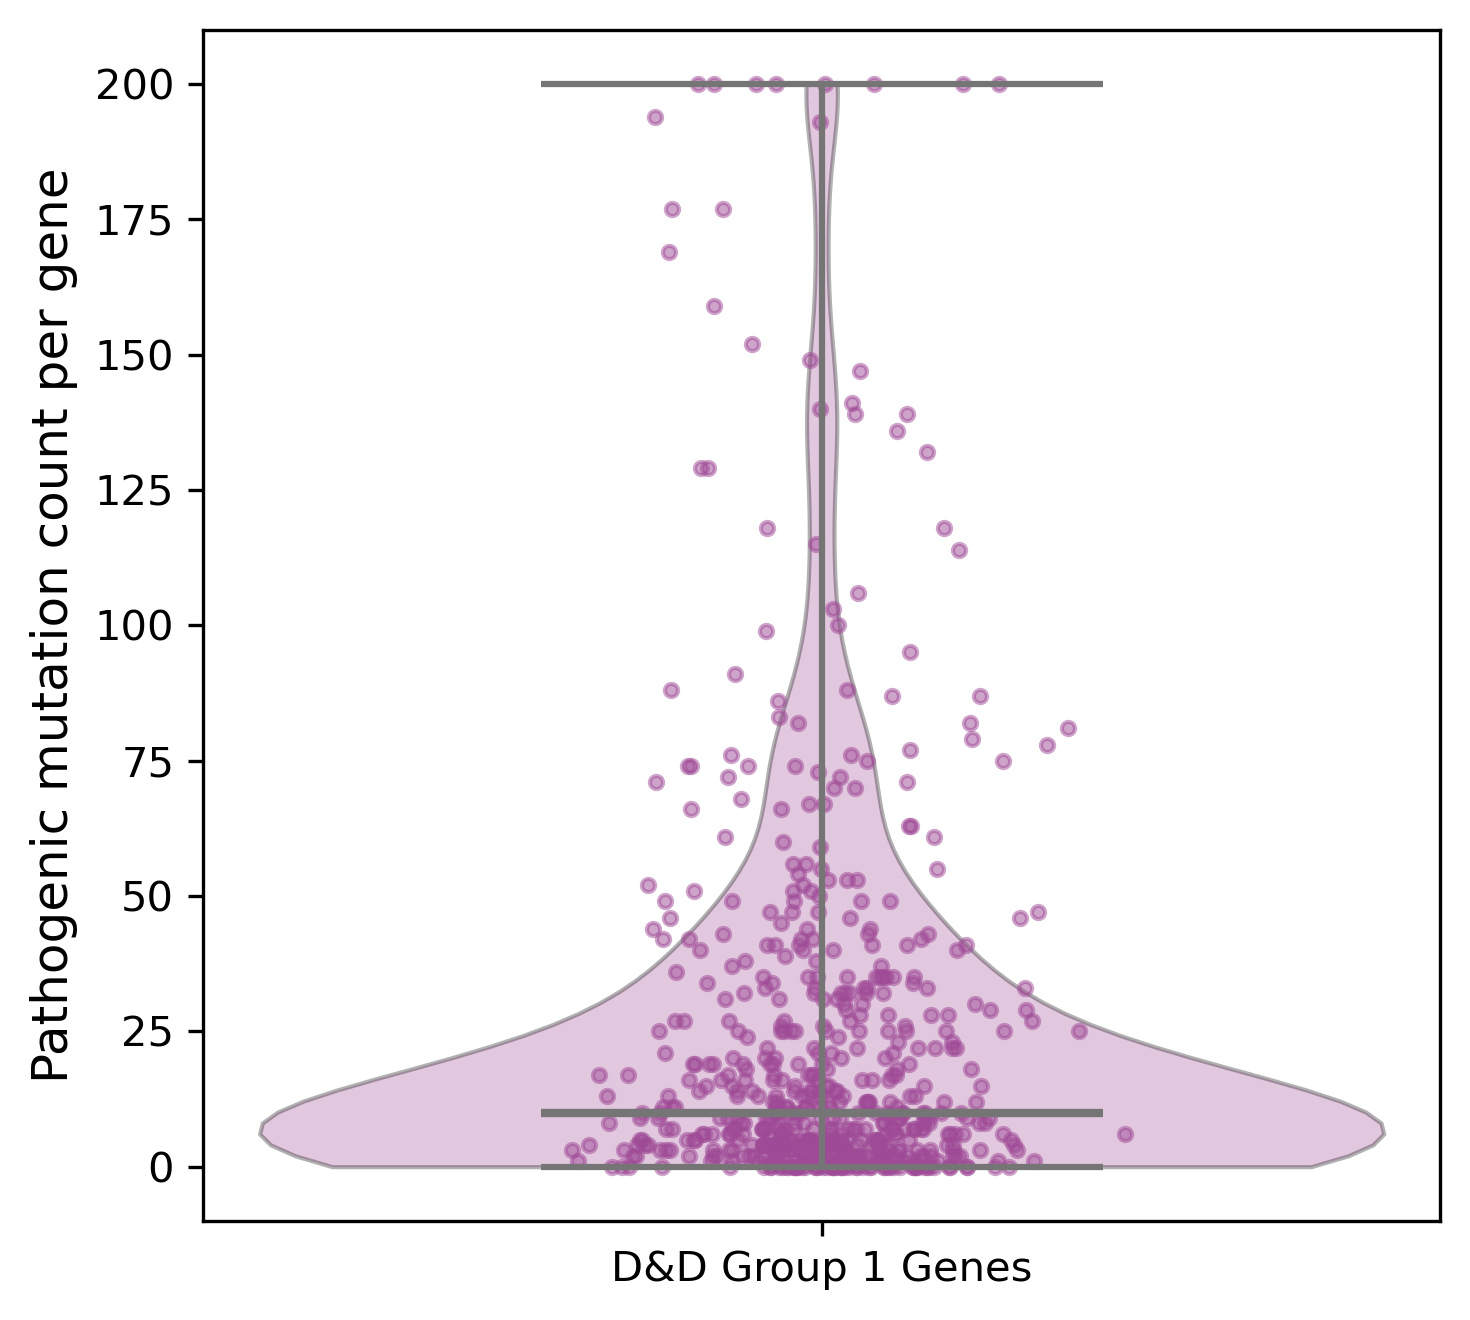

In [21]:
# let's plot just this combined dominant data
cols = [
    "total_dom_annot_from_clinvar_and_omim_plp"
]

plot_data = [[x if x < 200 else 200 for x in dom_clean["total_dom_annot_from_clinvar_and_omim_plp"].values]]

fig, ax = plt.subplots(figsize=(5, 4.5))

vp = ax.violinplot(
    plot_data,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

color_map=['#9f4a96']
for body, color in zip(vp["bodies"], color_map):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.3)

# Median
vp["cmedians"].set_color("#757575")
vp["cmedians"].set_linewidth(2)

# Extrema (min/max + connecting bar)
for key in ["cmins", "cmaxes", "cbars"]:
    vp[key].set_color("#757575")
    vp[key].set_linewidth(1.5)

ax.set_xticks(np.arange(1, len(plot_data) + 1))
ax.set_xticklabels(['D&D Group 1 Genes'], 
                   rotation=0)
color_map2 = ['#9f4a96']
for i, col in enumerate(plot_data, start=1):
    y = plot_data[i-1]
    x = np.random.normal(i, 0.04, size=len(y))  # jitter
    ax.scatter(x, y, s=10, alpha=0.5, color=color_map2[i-1])
#ax.set_yscale("log")
ax.set_ylabel("Pathogenic mutation count per gene", fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
# view a few example genes
dom_clean[dom_clean['gene'].isin(['MFN2', 'MYH7', 'NEFL', 'RHO','ALPL', 'COL4A4', 'VWF', 'PARN', 'STAT'])][['gene','total_dom_annot_from_clinvar_and_omim_plp']]

,gene,total_dom_annot_from_clinvar_and_omim_plp
31,ALPL,194
114,COL4A4,339
318,MFN2,55
333,MYH7,149
348,NEFL,44
372,PARN,70
434,RHO,86
577,VWF,159


In [32]:
# load s_het informaiton here

Index(['gene', 'GENE ID (HGNC)', 'DISEASE LABEL', 'DISEASE ID (MONDO)', 'MOI',
       'CLASSIFICATION', 'HI Score', '%HI', 'pLI', 'LOEUF', 'total_plp',
       'missense_plp', 'nonsense_plp', 'ensg', 'chrom', 'obs_lof', 'exp_lof',
       'prior_mean', 's_het', 'post_lower_95', 'post_upper_95',
       'indel_targetable_pre_NMD_assessment', 'num_indel_vars',
       'crisproff_targetable', 'num_crisproff_vars', 'base_editable',
       'num_base_editable_vars', 'excision_targetable', 'num_excision_vars',
       'num_excision_pairs', 'HPO_term_list', 'Approved name',
       'indel_pam_targetable', 'crisproff_pam_targetable',
       'base_edit_pam_targetable', 'excision_pam_targetable',
       'hets_across_strats', 'prop_hets_across_strats', 'num_indel_hets',
       'indel_hets_prop', 'num_crisproff_hets', 'crisproff_hets_prop',
       'num_base_edit_hets', 'base_edit_hets_prop', 'num_excision_hets',
       'excision_hets_prop', 'hets_across_strats_prePAM',
       'prop_hets_across_strats_pre

In [35]:
merged = dom_clean.merge(data[['gene','s_het']], on='gene',how='left')
merged.drop_duplicates(inplace=True)
merged

,counter,gene,total_dom_annot_plp_from_clinvar,total_dom_annot_mis_plp_from_clinvar,total_dom_annot_ns_plp_from_clinvar,total_dom_annot_from_clinvar_and_omim_plp,added_mutations,s_het
0,0,AARS1,4,2,0,10,6,0.022459
2,1,ABCB6,2,1,0,8,6,0.000834
4,2,ABCC6,1,0,1,74,73,0.000681
5,3,ABCC8,10,7,0,272,262,0.008893
7,4,ABCC9,6,6,0,63,57,0.020637
...,...,...,...,...,...,...,...,...
732,588,ZIC1,0,0,0,5,5,0.205882
733,589,ZMIZ1,4,1,2,25,21,0.209067
734,590,ZMYND8,1,0,0,1,0,0.254357
735,591,ZNF292,23,1,9,47,24,0.217299


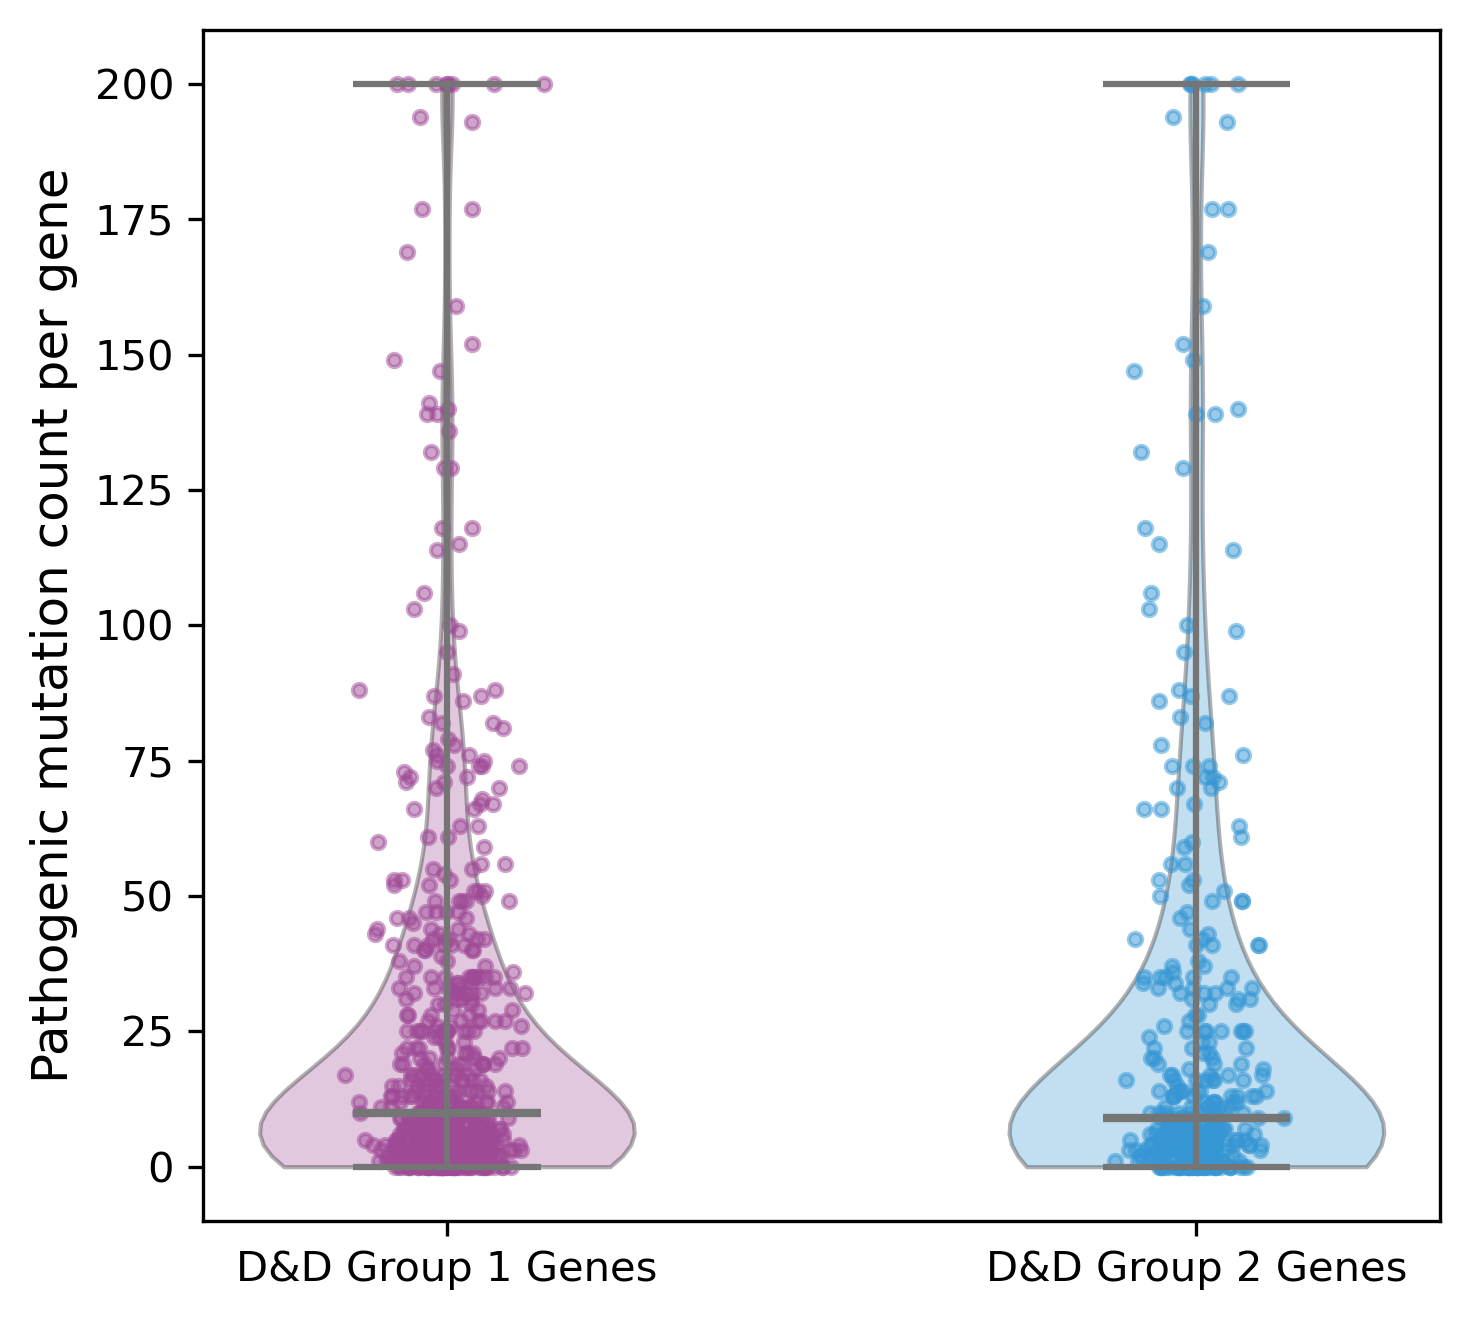

In [38]:
# also generate for group 2 genes

plot_data = [[x if x < 200 else 200 for x in dom_clean["total_dom_annot_from_clinvar_and_omim_plp"].values],
            [x if x<200 else 200 for x in (merged[merged['s_het']<0.1])['total_dom_annot_from_clinvar_and_omim_plp'].values]]

fig, ax = plt.subplots(figsize=(5, 4.5))

vp = ax.violinplot(
    plot_data,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

color_map=['#9f4a96', '#3697d4']
for body, color in zip(vp["bodies"], color_map):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.3)

# Median
vp["cmedians"].set_color("#757575")
vp["cmedians"].set_linewidth(2)

# Extrema (min/max + connecting bar)
for key in ["cmins", "cmaxes", "cbars"]:
    vp[key].set_color("#757575")
    vp[key].set_linewidth(1.5)

ax.set_xticks(np.arange(1, len(plot_data) + 1))
ax.set_xticklabels(['D&D Group 1 Genes', 'D&D Group 2 Genes'], 
                   rotation=0)
color_map2 = ['#9f4a96', '#3697d4']
for i, col in enumerate(plot_data, start=1):
    y = plot_data[i-1]
    x = np.random.normal(i, 0.04, size=len(y))  # jitter
    ax.scatter(x, y, s=10, alpha=0.5, color=color_map2[i-1])
#ax.set_yscale("log")
ax.set_ylabel("Pathogenic mutation count per gene", fontsize=12)

plt.tight_layout()
plt.show()



In [43]:
print('D&D Group2 Gene Summary Statistics')
print(np.mean([x if x<200 else 200 for x in (merged[merged['s_het']<0.1])['total_dom_annot_from_clinvar_and_omim_plp'].values]))
print(np.median([x if x<200 else 200 for x in (merged[merged['s_het']<0.1])['total_dom_annot_from_clinvar_and_omim_plp'].values]))

D&D Group2 Gene Summary Statistics
26.380165289256198
9.0


In [ ]:
# average and median values
print('Average number of pathogenic mutations per gene: ' + str(np.mean(dom_clean['total_dom_annot_and_omim_plp'])))
print('Median number of pathogenic mutations per gene: ' + str(np.median(dom_clean['total_dom_annot_and_omim_plp'])))

In [30]:
# Percent of genes with more than 4 dominant pathogenic mutations
total_genes = len(dom_clean['gene'].unique())
four_guides = dom_clean[dom_clean['total_dom_annot_and_omim_plp']>=4]
print('Percent of all D&D genes with more than 4 dominant pathogenic mutations: ' + str((len(four_guides.gene)/total_genes)*100) + '%')
print('Number of D&D genes with more than 4 dominant pathogenic mutations: ' + str(len(four_guides.gene)))

Percent of all D&D genes with more than 4 dominant pathogenic mutations: 75.21079258010118%
Number of D&D genes with more than 4 dominant pathogenic mutations: 446


In [48]:
g2_genes.sort_values('total_dom_annot_and_omim_plp', ascending=False)[0:20] # view a few group2 genes

,gene,total_dom_annot_plp,total_dom_annot_mis_plp,total_dom_annot_ns_plp,total_dom_annot_and_omim_plp,added_mutations,s_het
180,COL4A4,73,36,9,339,266,0.014433
5,ABCC8,10,7,0,272,262,0.008893
681,SERPING1,170,61,21,262,92,0.051901
673,SDHA,12,4,1,244,232,0.047165
118,CASR,12,11,0,238,226,0.052534
184,COL6A2,10,4,2,204,194,0.011007
51,ALPL,10,8,0,194,184,0.011099
654,RYR1,91,69,8,193,102,0.022355
17,ACTA1,32,31,0,177,145,0.008776
519,NEB,0,0,0,177,177,0.018070


In [39]:
# average and median values of group 2 genes
print('Average number of pathogenic mutations per gene: ' + str(np.mean(g2_genes['total_dom_annot_and_omim_plp'])))
print('Median number of pathogenic mutations per gene: ' + str(np.median(g2_genes['total_dom_annot_and_omim_plp'])))

Average number of pathogenic mutations per gene: 27.36914600550964
Median number of pathogenic mutations per gene: 9.0


In [41]:
# Percent of genes with more than 4 dominant pathogenic mutations (group 2 genes)
total_genes = len(g2_genes['gene'].unique())
four_guides = g2_genes[g2_genes['total_dom_annot_and_omim_plp']>=4]
print('Percent of all D&D genes with more than 4 dominant pathogenic mutations: ' + str((len(four_guides.gene)/total_genes)*100) + '%')
print('Number of D&D genes with more than 4 dominant pathogenic mutations: ' + str(len(four_guides.gene)))

Percent of all D&D genes with more than 4 dominant pathogenic mutations: 72.1763085399449%
Number of D&D genes with more than 4 dominant pathogenic mutations: 262


In [50]:
# # save this revised dominant mutation information
# dom_clean.rename(columns={'total_dom_annot_plp':'total_dom_annot_plp_from_clinvar', 'total_dom_annot_mis_plp':'total_dom_annot_mis_plp_from_clinvar', 'total_dom_annot_ns_plp':'total_dom_annot_ns_plp_from_clinvar', 'total_dom_annot_and_omim_plp':'total_dom_annot_from_clinvar_and_omim_plp', 'added_dom_mutations_from_omim':'added_mutations'}, inplace=True)
# dom_clean.to_csv('ClinVar_Omim_dom_annot.csv')

# Reload data to re-plot


In [2]:
dom_clean = pd.read_csv(os.path.join(os.getcwd(), "linked_dom_annotations.csv"))
dom_clean

,counter,gene,total_dom_annot_plp_from_clinvar,total_dom_annot_mis_plp_from_clinvar,total_dom_annot_ns_plp_from_clinvar,total_dom_annot_from_clinvar_and_omim_plp,added_mutations
0,0,AARS1,4,2,0,10,6
1,1,ABCB6,2,1,0,8,6
2,2,ABCC6,1,0,1,74,73
3,3,ABCC8,10,7,0,272,262
4,4,ABCC9,6,6,0,63,57
...,...,...,...,...,...,...,...
588,588,ZIC1,0,0,0,5,5
589,589,ZMIZ1,4,1,2,25,21
590,590,ZMYND8,1,0,0,1,0
591,591,ZNF292,23,1,9,47,24


In [7]:
# pick out a few additional genes to highlight, based on broad organ system involvements
# (right now we've seen cardio, nervous system, how about some immune and others)
genes_to_highlight = ['BEST1','RHO', 'TNPO3','INS','ALPL','STAT1', 'SFTPA1','VWF','NAF1', 'CLCN7', 'FAM111B','PARN']
vis_df = dom_clean[dom_clean['gene'].isin(genes_to_highlight)][['gene', 'total_dom_annot_from_clinvar_and_omim_plp']]
vis_df.rename(columns={'total_dom_annot_from_clinvar_and_omim_plp':'dom_path_muts'},inplace=True)
vis_df[vis_df['dom_path_muts']>5]

,gene,dom_path_muts
31,ALPL,194
53,BEST1,56
105,CLCN7,12
372,PARN,70
434,RHO,86
507,STAT1,68
541,TNPO3,7
577,VWF,159
